# 03 - Explainability with SHAP

This notebook explains the final fraud detection model selected during modeling.

**Final modeling decision:**
- Model: Random Forest
- Feature version: Version B - Without ExtremeFlags
- Expected benchmark: PR-AUC around 0.816 and ROC-AUC around 0.986

The goal is to translate model behavior into feature-level explanations that can support analyst review and a future LLM-powered explanation layer.

## 1. Setup

This section imports the libraries used for modeling, evaluation, and SHAP explainability. The notebook keeps the same `random_state=42` used in the modeling workflow so results remain reproducible.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

try:
    from imblearn.over_sampling import SMOTE
except ImportError as exc:
    raise ImportError(
        "imbalanced-learn is required for SMOTE. Install it with: pip install imbalanced-learn"
    ) from exc

try:
    import shap
except ImportError as exc:
    raise ImportError("SHAP is required for this notebook. Install it with: pip install shap") from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.20
SHAP_SAMPLE_SIZE = 2000

DATA_PATH = Path("data/processed/creditcard_cleaned_engineered.csv")
SHAP_PLOTS_DIR = Path("outputs/plots/shap")
SHAP_IMPORTANCE_PATH = Path("outputs/shap_feature_importance.csv")

SHAP_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SHAP_IMPORTANCE_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"SHAP plots will be saved to: {SHAP_PLOTS_DIR}")
print(f"SHAP feature importance table will be saved to: {SHAP_IMPORTANCE_PATH}")

SHAP plots will be saved to: outputs\plots\shap
SHAP feature importance table will be saved to: outputs\shap_feature_importance.csv


**Recruiter-friendly takeaway:** This notebook is designed like a production analysis handoff: it defines paths, constants, and reproducible settings up front, then saves every explainability artifact to a predictable output folder.

## 2. Load the Processed Dataset

The processed dataset already includes cleaned transaction fields and engineered features from the earlier EDA and feature engineering workflow.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Fraud rate:", round(df["Class"].mean() * 100, 4), "%")
display(df.head())

Dataset shape: (283726, 45)
Fraud rate: 0.1667 %


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V7_ExtremeFlag,V8_ExtremeFlag,V23_ExtremeFlag,LogAmount,IsZeroAmount,Hour,HourOfDay,Day,HourSin,HourCos
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0,0,0,5.014760,0,0,0,0,0.0,1.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0,0,0,1.305626,0,0,0,0,0.0,1.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0,0,0,5.939276,0,0,0,0,0.0,1.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0,0,0,4.824306,0,0,0,0,0.0,1.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0,0,0,4.262539,0,0,0,0,0.0,1.0


**Recruiter-friendly takeaway:** The explainability workflow starts from the same processed data used for modeling, which keeps the analysis consistent and avoids explaining a different feature space than the one used to make predictions.

## 3. Create Version B Features

Version B intentionally removes all `_ExtremeFlag` columns. This tests and explains the final model without explicit outlier indicator shortcuts, using the feature version selected in the modeling notebook.

In [3]:
TARGET = "Class"
raw_or_intermediate_cols = ["Time", "Amount", "Hour", "HourOfDay"]
extreme_flag_cols = [col for col in df.columns if col.endswith("_ExtremeFlag")]

base_drop_cols = [TARGET] + [col for col in raw_or_intermediate_cols if col in df.columns]
feature_cols_A = [col for col in df.columns if col not in base_drop_cols]
feature_cols_B = [col for col in feature_cols_A if col not in extreme_flag_cols]

X = df[feature_cols_B].copy()
y = df[TARGET].copy()

print(f"ExtremeFlag columns removed: {len(extreme_flag_cols)}")
print(extreme_flag_cols)
print(f"Version B feature count: {len(feature_cols_B)}")
print(feature_cols_B)

assert not any(col.endswith("_ExtremeFlag") for col in X.columns), "Version B must exclude ExtremeFlag columns."

ExtremeFlag columns removed: 7
['V1_ExtremeFlag', 'V2_ExtremeFlag', 'V3_ExtremeFlag', 'V5_ExtremeFlag', 'V7_ExtremeFlag', 'V8_ExtremeFlag', 'V23_ExtremeFlag']
Version B feature count: 33
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'LogAmount', 'IsZeroAmount', 'Day', 'HourSin', 'HourCos']


**Recruiter-friendly takeaway:** The model is being explained under the exact final feature decision: no `_ExtremeFlag` columns are allowed, so the explanations reflect signal learned from the underlying transaction variables and engineered time/amount features.

## 4. Stratified Train-Test Split

Fraud is rare, so the split is stratified to preserve the fraud rate in both train and test sets. The test set remains untouched and imbalanced.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", round(y_train.mean() * 100, 4), "%")
print("Test fraud rate:", round(y_test.mean() * 100, 4), "%")

Train shape: (226980, 33)
Test shape: (56746, 33)
Train fraud rate: 0.1665 %
Test fraud rate: 0.1674 %


**Recruiter-friendly takeaway:** Stratification protects the evaluation from accidental class imbalance shifts, which is especially important when the positive class is extremely rare.

## 5. Apply SMOTE to Training Data Only

SMOTE is applied only after the split and only to `X_train`. This prevents synthetic fraud examples from leaking into the test set.

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, " Fraud rate:", round(y_train.mean() * 100, 4), "%")
print("After SMOTE: ", X_train_resampled.shape, " Fraud rate:", round(y_train_resampled.mean() * 100, 2), "%")

Before SMOTE: (226980, 33)  Fraud rate: 0.1665 %
After SMOTE:  (453204, 33)  Fraud rate: 50.0 %


**Recruiter-friendly takeaway:** This is the correct imbalance workflow: the model gets help learning minority-class patterns during training, while evaluation remains honest on real, imbalanced test data.

## 6. Train the Final Random Forest Model

This reproduces the final model decision from the modeling notebook. The trained model stays in memory for explainability and is not saved to disk.

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Random Forest training complete.")

Random Forest training complete.


**Recruiter-friendly takeaway:** The explainability analysis uses the same final model family and feature version selected by performance, making the SHAP results directly connected to the project decision.

## 7. Brief Evaluation Check

Before explaining the model, we confirm that this reproduction lands close to the modeling notebook benchmark: PR-AUC around 0.816 and ROC-AUC around 0.986.

,precision,recall,f1,roc_auc,pr_auc_avg_precision
0,0.924051,0.768421,0.83908,0.986168,0.816021


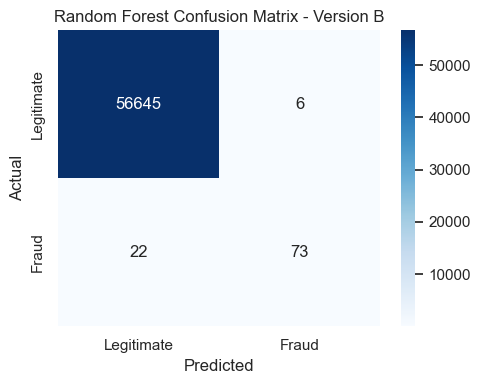

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [7]:
y_score = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.50).astype(int)

metrics = {
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score),
    "pr_auc_avg_precision": average_precision_score(y_test, y_score),
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"],
)
plt.title("Random Forest Confusion Matrix - Version B")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"], zero_division=0))

**Recruiter-friendly takeaway:** The brief evaluation confirms that the explainability work is attached to a strong fraud model rather than a toy example. PR-AUC is emphasized because it is more meaningful than accuracy when fraud cases are rare.

## 8. Compute SHAP Values on a Test Sample

Tree SHAP explains how each feature pushes the Random Forest prediction higher or lower. To keep runtime practical, this notebook samples 2,000 rows from the test set by default.

In [8]:
def get_positive_class_shap_values(shap_values):
    """Return SHAP values for the fraud class across older and newer SHAP APIs."""
    if isinstance(shap_values, list):
        return shap_values[1]
    values = np.asarray(shap_values)
    if values.ndim == 3:
        return values[:, :, 1]
    return values


def get_positive_expected_value(expected_value):
    values = np.asarray(expected_value)
    if values.ndim > 0 and len(values) > 1:
        return values[1]
    return float(values)


sample_n = min(SHAP_SAMPLE_SIZE, len(X_test))
X_shap = X_test.sample(n=sample_n, random_state=RANDOM_STATE)
y_shap = y_test.loc[X_shap.index]
y_score_shap = pd.Series(y_score, index=X_test.index).loc[X_shap.index]

explainer = shap.TreeExplainer(rf_model)
raw_shap_values = explainer.shap_values(X_shap)
shap_values_fraud = get_positive_class_shap_values(raw_shap_values)
expected_value_fraud = get_positive_expected_value(explainer.expected_value)

print("SHAP sample shape:", X_shap.shape)
print("SHAP values shape:", shap_values_fraud.shape)
print("Expected fraud-class model output:", expected_value_fraud)

SHAP sample shape: (2000, 33)
SHAP values shape: (2000, 33)
Expected fraud-class model output: 0.49999999999999784


**Recruiter-friendly takeaway:** Sampling makes the explainability step fast enough for an applied workflow while still using real test-set examples. The SHAP values show which features most influence the model's fraud probability.

## 9. Global SHAP Feature Importance

Global SHAP importance ranks features by their average absolute impact on fraud predictions across the sampled test rows.

,feature,mean_abs_shap
0,V14,0.079552
1,V12,0.076223
2,V4,0.059272
3,V3,0.053246
4,V10,0.046906
5,V11,0.039443
6,V17,0.027855
7,V16,0.018720
8,V7,0.010721
9,V1,0.010218


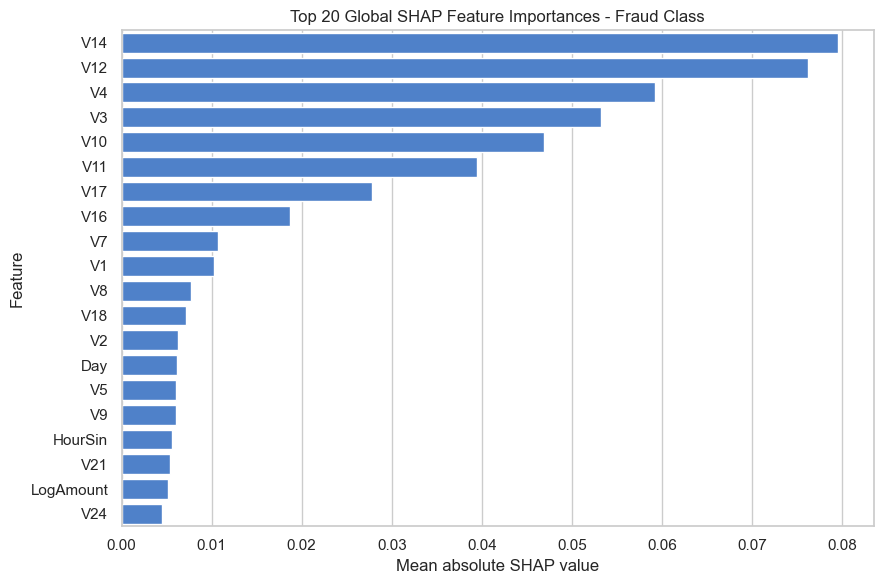

Saved global SHAP feature importance plot to: outputs\plots\shap\global_shap_feature_importance_bar.png
Saved SHAP feature importance table to: outputs\shap_feature_importance.csv


In [9]:
shap_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values_fraud).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance.to_csv(SHAP_IMPORTANCE_PATH, index=False)
display(shap_importance.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=shap_importance.head(20),
    x="mean_abs_shap",
    y="feature",
    color="#3b7ddd",
)
plt.title("Top 20 Global SHAP Feature Importances - Fraud Class")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
global_bar_path = SHAP_PLOTS_DIR / "global_shap_feature_importance_bar.png"
plt.savefig(global_bar_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved global SHAP feature importance plot to: {global_bar_path}")
print(f"Saved SHAP feature importance table to: {SHAP_IMPORTANCE_PATH}")

**Recruiter-friendly takeaway:** This table turns a complex Random Forest into a ranked list of drivers. It helps stakeholders quickly see which transformed transaction patterns matter most to fraud risk.

## 10. SHAP Summary Plot

The summary plot shows both importance and direction. Each dot is one transaction: red means a high feature value and blue means a low feature value.

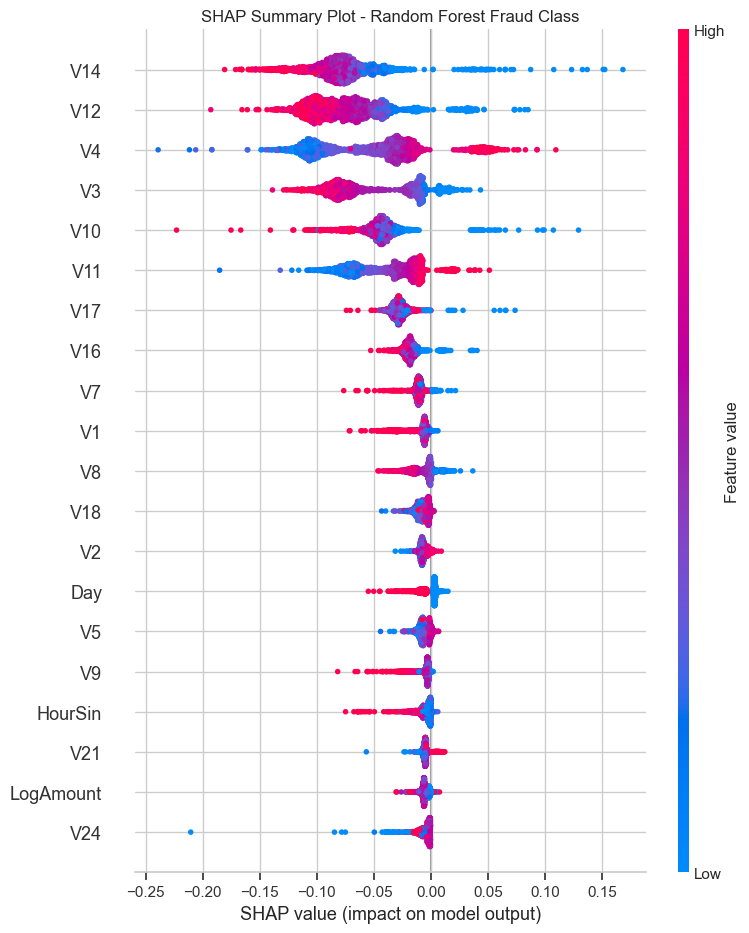

Saved SHAP summary plot to: outputs\plots\shap\shap_summary_plot.png


In [10]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_fraud,
    X_shap,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary Plot - Random Forest Fraud Class")
plt.tight_layout()
summary_path = SHAP_PLOTS_DIR / "shap_summary_plot.png"
plt.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved SHAP summary plot to: {summary_path}")

**Recruiter-friendly takeaway:** The summary plot answers two business questions at once: which variables matter most, and whether high or low values of those variables tend to push a transaction toward fraud.

## 11. Local Explanations for High-Risk Fraud Predictions

This section selects fraud cases that the model scored as high risk and explains the strongest feature contributions for each transaction.

,actual,predicted,fraud_probability
150084,1,1,1.0
150420,1,1,1.0
43498,1,1,1.0


High-risk true fraud #1 | index=150084 | fraud_probability=1.0000


,feature,feature_value,shap_value,abs_shap_value
13,V14,-14.116156,0.124794,0.124794
9,V10,-12.965481,0.091737,0.091737
11,V12,-17.182918,0.078739,0.078739
16,V17,-18.716765,0.061862,0.061862
3,V4,8.010823,0.051075,0.051075
10,V11,8.688308,0.043628,0.043628
15,V16,-12.375334,0.040772,0.040772
2,V3,-13.030455,0.030450,0.030450
6,V7,-12.229608,0.017220,0.017220
7,V8,4.971232,-0.016878,0.016878


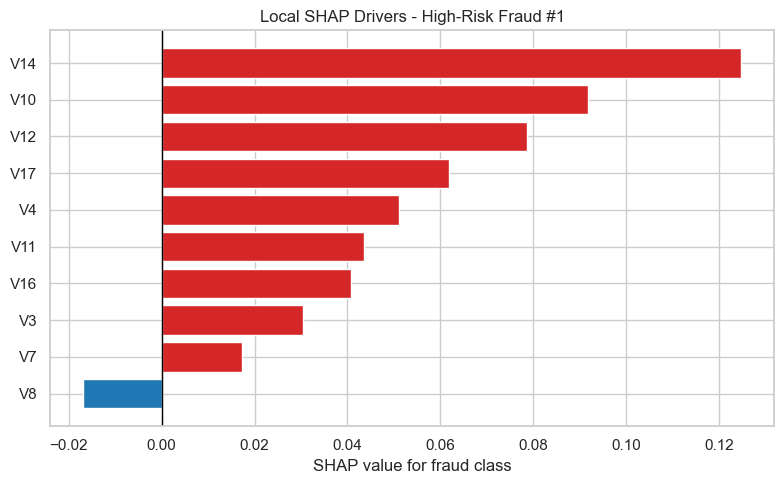

Saved local high-risk fraud explanation to: outputs\plots\shap\local_high_risk_fraud_1_index_150084.png
High-risk true fraud #2 | index=150420 | fraud_probability=1.0000


,feature,feature_value,shap_value,abs_shap_value
13,V14,-8.334763,0.113635,0.113635
9,V10,-17.141514,0.097756,0.097756
11,V12,-13.580147,0.082587,0.082587
16,V17,-17.270985,0.064233,0.064233
3,V4,8.046075,0.055356,0.055356
15,V16,-10.196334,0.044537,0.044537
10,V11,5.902400,0.043698,0.043698
2,V3,-19.629515,0.030880,0.030880
6,V7,-21.359738,0.019817,0.019817
26,V27,-2.634761,-0.009115,0.009115


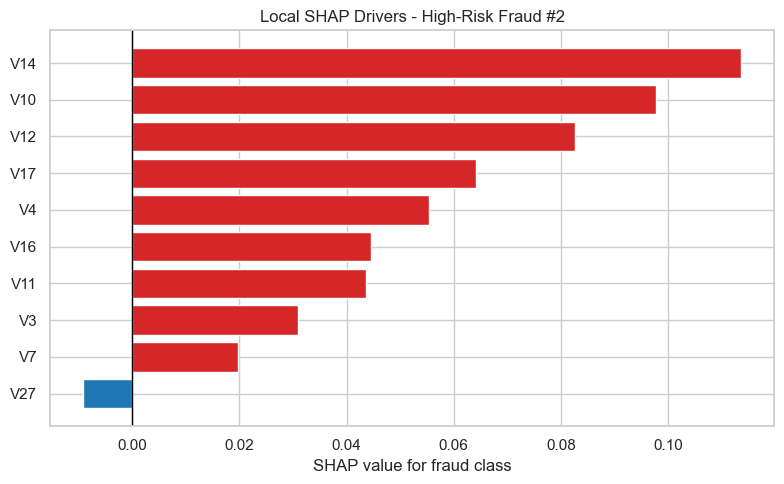

Saved local high-risk fraud explanation to: outputs\plots\shap\local_high_risk_fraud_2_index_150420.png
High-risk true fraud #3 | index=43498 | fraud_probability=1.0000


,feature,feature_value,shap_value,abs_shap_value
13,V14,-6.917640,0.120575,0.120575
9,V10,-14.557159,0.093505,0.093505
11,V12,-10.380073,0.083052,0.083052
16,V17,-20.254556,0.067348,0.067348
3,V4,9.249459,0.051235,0.051235
15,V16,-10.328242,0.043769,0.043769
10,V11,4.392436,0.043485,0.043485
2,V3,-17.880127,0.028751,0.028751
6,V7,-18.014660,0.020606,0.020606
7,V8,5.522162,-0.014609,0.014609


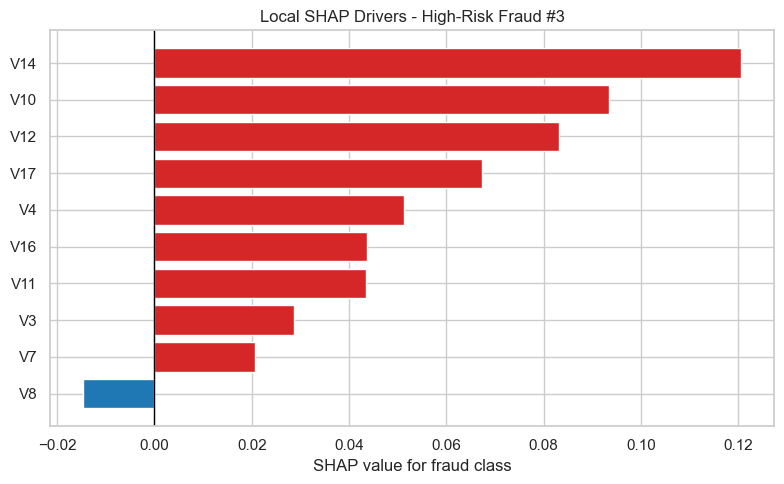

Saved local high-risk fraud explanation to: outputs\plots\shap\local_high_risk_fraud_3_index_43498.png


In [11]:
test_results = X_test.copy()
test_results["actual"] = y_test
test_results["predicted"] = y_pred
test_results["fraud_probability"] = y_score

high_risk_frauds = (
    test_results[(test_results["actual"] == 1) & (test_results["predicted"] == 1)]
    .sort_values("fraud_probability", ascending=False)
    .head(3)
)

display(high_risk_frauds[["actual", "predicted", "fraud_probability"]])

for rank, idx in enumerate(high_risk_frauds.index, start=1):
    row = X_test.loc[[idx]]
    row_shap = get_positive_class_shap_values(explainer.shap_values(row))[0]
    local_df = (
        pd.DataFrame({
            "feature": X_test.columns,
            "feature_value": row.iloc[0].values,
            "shap_value": row_shap,
            "abs_shap_value": np.abs(row_shap),
        })
        .sort_values("abs_shap_value", ascending=False)
        .head(10)
    )

    print(f"High-risk true fraud #{rank} | index={idx} | fraud_probability={test_results.loc[idx, 'fraud_probability']:.4f}")
    display(local_df)

    plt.figure(figsize=(8, 5))
    colors = np.where(local_df["shap_value"] >= 0, "#d62728", "#1f77b4")
    plt.barh(local_df["feature"][::-1], local_df["shap_value"][::-1], color=colors[::-1])
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Local SHAP Drivers - High-Risk Fraud #{rank}")
    plt.xlabel("SHAP value for fraud class")
    plt.tight_layout()
    local_path = SHAP_PLOTS_DIR / f"local_high_risk_fraud_{rank}_index_{idx}.png"
    plt.savefig(local_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved local high-risk fraud explanation to: {local_path}")

**Recruiter-friendly takeaway:** Local explanations make the model reviewable at the individual-transaction level. Instead of only saying "high risk," the workflow identifies the features that pushed that specific transaction toward a fraud decision.

## 12. Local Explanations for False Negatives

False negatives are actual fraud cases that the model missed at the default 0.50 threshold. These are important because they show where fraud patterns may be subtle, ambiguous, or below the decision cutoff.

,actual,predicted,fraud_probability
14285,1,0,0.440
6932,1,0,0.432
4886,1,0,0.372


False negative #1 | index=14285 | fraud_probability=0.4400
Positive SHAP values pushed toward fraud; negative SHAP values pushed away from fraud.


,feature,feature_value,shap_value,abs_shap_value
3,V4,2.675688,0.132359,0.132359
31,HourSin,0.965926,-0.132355,0.132355
11,V12,-0.491243,-0.071421,0.071421
13,V14,-2.238622,0.060428,0.060428
9,V10,-0.369909,-0.044204,0.044204
23,V24,-0.592077,-0.041584,0.041584
18,V19,-1.306995,0.018923,0.018923
16,V17,1.776454,0.018790,0.018790
17,V18,1.149282,0.013096,0.013096
4,V5,0.990075,0.011279,0.011279


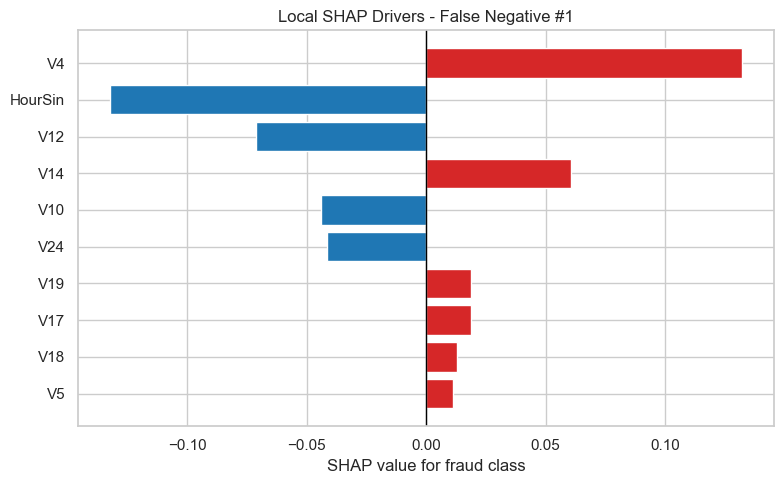

Saved false-negative explanation to: outputs\plots\shap\local_false_negative_1_index_14285.png
False negative #2 | index=6932 | fraud_probability=0.4320
Positive SHAP values pushed toward fraud; negative SHAP values pushed away from fraud.


,feature,feature_value,shap_value,abs_shap_value
6,V7,5.431271,-0.271365,0.271365
13,V14,-3.738023,0.088487,0.088487
11,V12,-6.998042,0.070277,0.070277
28,LogAmount,7.501458,-0.065175,0.065175
16,V17,-5.136135,0.058622,0.058622
3,V4,4.853894,0.051991,0.051991
9,V10,-1.987773,0.046369,0.046369
15,V16,-2.013543,0.032676,0.032676
10,V11,4.690396,0.032207,0.032207
20,V21,-1.052368,-0.020144,0.020144


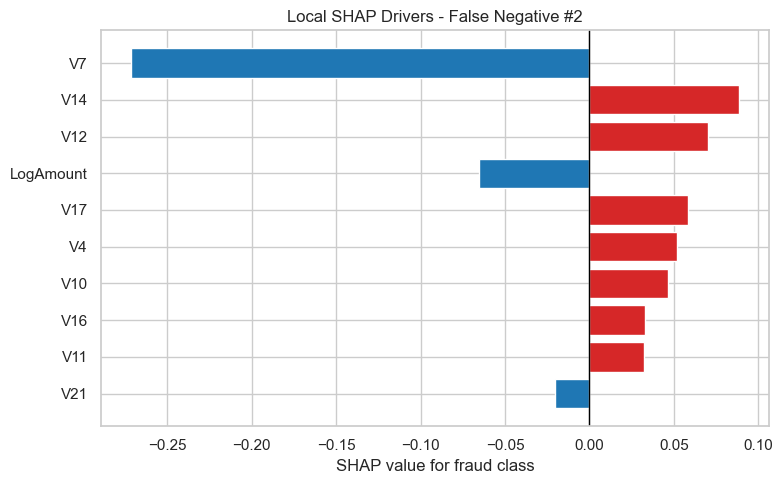

Saved false-negative explanation to: outputs\plots\shap\local_false_negative_2_index_6932.png
False negative #3 | index=4886 | fraud_probability=0.3720
Positive SHAP values pushed toward fraud; negative SHAP values pushed away from fraud.


,feature,feature_value,shap_value,abs_shap_value
13,V14,-1.470102,-0.097030,0.097030
16,V17,-4.781831,0.087047,0.087047
11,V12,-6.560124,0.083095,0.083095
3,V4,2.330243,0.073724,0.073724
2,V3,-0.359745,-0.065521,0.065521
9,V10,-1.525412,-0.063786,0.063786
32,HourCos,0.965926,-0.050265,0.050265
6,V7,0.562320,-0.037902,0.037902
10,V11,2.032912,0.034932,0.034932
15,V16,-2.282194,0.034706,0.034706


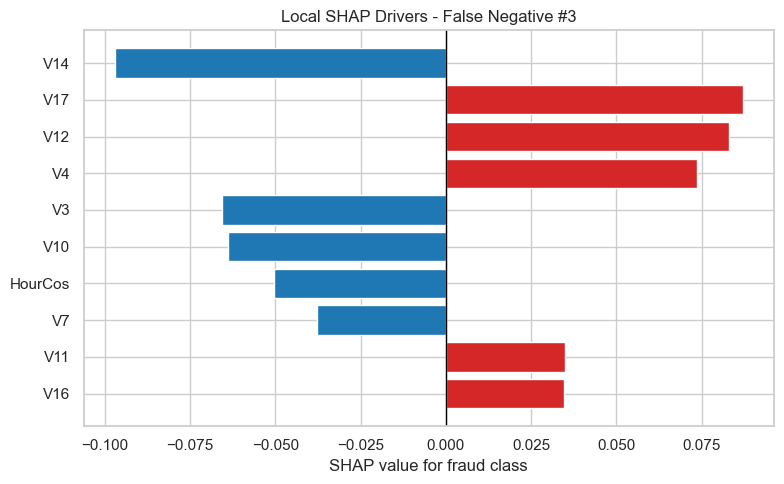

Saved false-negative explanation to: outputs\plots\shap\local_false_negative_3_index_4886.png


In [12]:
false_negatives = (
    test_results[(test_results["actual"] == 1) & (test_results["predicted"] == 0)]
    .sort_values("fraud_probability", ascending=False)
    .head(3)
)

display(false_negatives[["actual", "predicted", "fraud_probability"]])

if false_negatives.empty:
    print("No false negatives were found at the 0.50 threshold in this test split.")
else:
    for rank, idx in enumerate(false_negatives.index, start=1):
        row = X_test.loc[[idx]]
        row_shap = get_positive_class_shap_values(explainer.shap_values(row))[0]
        local_df = (
            pd.DataFrame({
                "feature": X_test.columns,
                "feature_value": row.iloc[0].values,
                "shap_value": row_shap,
                "abs_shap_value": np.abs(row_shap),
            })
            .sort_values("abs_shap_value", ascending=False)
            .head(10)
        )

        print(f"False negative #{rank} | index={idx} | fraud_probability={test_results.loc[idx, 'fraud_probability']:.4f}")
        print("Positive SHAP values pushed toward fraud; negative SHAP values pushed away from fraud.")
        display(local_df)

        plt.figure(figsize=(8, 5))
        colors = np.where(local_df["shap_value"] >= 0, "#d62728", "#1f77b4")
        plt.barh(local_df["feature"][::-1], local_df["shap_value"][::-1], color=colors[::-1])
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Local SHAP Drivers - False Negative #{rank}")
        plt.xlabel("SHAP value for fraud class")
        plt.tight_layout()
        local_path = SHAP_PLOTS_DIR / f"local_false_negative_{rank}_index_{idx}.png"
        plt.savefig(local_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved false-negative explanation to: {local_path}")

**Recruiter-friendly takeaway:** False-negative explanations are especially useful for model improvement. They reveal which features lowered the fraud score, helping analysts understand missed cases and decide whether threshold tuning, new features, or additional review rules are needed.

## 13. How SHAP Connects to the Future LLM Fraud Explanation Layer

SHAP provides model-grounded reasons for each fraud prediction. It identifies which features pushed the Random Forest score higher or lower, so the explanation stays tied to the trained model's actual behavior.

The future LLM layer will not replace SHAP or invent new reasoning. Its role will be to convert these SHAP outputs into human-readable fraud investigation explanations that analysts can quickly understand and act on.

A practical LLM explanation layer could use:
- The model's fraud probability
- The top positive SHAP drivers that increased fraud risk
- The top negative SHAP drivers that reduced fraud risk
- Whether the case was a true positive, false positive, or false negative during evaluation
- Plain-language feature descriptions for fields such as `LogAmount`, `IsZeroAmount`, `HourSin`, and anonymized PCA components

The LLM should ground every explanation in the SHAP table for that transaction. For example, it can say that a case was flagged because several features strongly pushed the fraud score upward, while also noting any features that reduced confidence.

This creates a bridge between predictive modeling and analyst-facing decision support: the Random Forest produces the risk score, SHAP produces the evidence, and the LLM translates that evidence into a concise explanation for fraud operations.